In [ ]:
!pip install "textdistance[extras]"
!pip install cerebras-cloud-sdk



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.6/126.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 3.3 MB/s eta 0:00:00


In [ ]:
# !pip install -q -U trl transformers peft accelerate bitsandbyte

!pip install --upgrade --no-cache-dir "unsloth[colab-new]"

!pip install vllm==0.13.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 291.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 390.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 278.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 391.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 384.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 409.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 406.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 365.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 299.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 218.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 308.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=dead73741d3862e02262f22713ef92bd40ff94e83c9ac1ec6566bd84f010f6a2
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
# @title Imports & global config (paths, seeds)

# import unsloth
# from unsloth import FastLanguageModel
import os, gc, re, sqlite3, random
import csv, sys
from pandasql import sqldf
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from datasets import Dataset, DatasetDict
from transformers import TrainingArguments, pipeline
from peft import PeftModel

# ----- Repro -----
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

# ----- Config générale -----
MODEL_ID = "seeklhy/OmniSQL-7B"
MAX_EVAL_SAMPLES = 200
DO_TRAIN = True

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATA_PATH = Path("/content/drive/MyDrive/notebook_drive")
DEFAULT_DATA_DIR = Path("/content") if Path("/content").exists() else Path("/mnt/data")
DATA_DIR = DRIVE_DATA_PATH if DRIVE_DATA_PATH.exists() else DEFAULT_DATA_DIR

qwen_path = DATA_DIR / "omni_sql_dataset" / "qwen_7b_finetune.csv"
gptoss_path = DATA_DIR / "omni_sql_dataset" / "gpt_oss_120b_finetune.csv"
deepseek_path = DATA_DIR / "advanced_dataset" / "deepseek_candidates.csv"
schema_path   = DATA_DIR / "context.txt"
validator_dir = DATA_DIR / "pgadmin_exports"


business_schema = DATA_DIR / "full_context" / "business_context_sfil.md"
new_sql_schema = DATA_DIR / "full_context" / "schema_business_context.json"
short_sql_schema = DATA_DIR / "full_context" / "schema_sqlite.sql"


Mounted at /content/drive


In [ ]:
with open(new_sql_schema, "r", encoding="utf-8") as f:
    sfil_sql_schema = f.read().strip()

with open(short_sql_schema, "r", encoding="utf-8") as f:
    sfil_short_sql_schema = f.read().strip()

sfil_schema = sfil_sql_schema + "\n" + sfil_short_sql_schema

df1 = pd.read_csv(qwen_path)
df2 = pd.read_csv(gptoss_path)
df_test = pd.read_csv(deepseek_path)

train_val_df = pd.concat([df1, df2], ignore_index=True)

train_val_df = train_val_df.dropna(subset=["question", "response"]).copy()
train_val_df["text_query"] = train_val_df["question"].astype(str).str.strip()
train_val_df["sql_query"]  = train_val_df["response"].astype(str).str.strip()
train_val_df = train_val_df.drop_duplicates(subset=["question", "response"]).reset_index(drop=True)

df_test = df_test.dropna(subset=["question_fr", "sql"]).copy()
df_test["text_query"] = df_test["question_fr"].astype(str).str.strip()
df_test["sql_query"]  = df_test["sql"].astype(str).str.strip()
df_test = df_test.drop_duplicates(subset=["text_query", "sql_query"]).reset_index(drop=True)

def build_prompt(question: str, tokenizer) -> str:
    input_prompt_template = (
        "Task Overview:\n"
        "You are a data science expert. Below, you are provided with a database schema and a natural language question. "
        "Your task is to understand the schema and generate a valid SQL query to answer the question.\n\n"
        "Database Engine:\nSQLite\n\n"
        "Database Schema:\n{db_details}\n\n"
        "Question:\n{question}\n\n"
        "Instructions:\n"
        "- Make sure you only output the information that is asked in the question.\n"
        "- The generated query should return all of the information asked in the question.\n"
        "- Before generating the final SQL query, please think through the steps.\n\n"
        "Output Format:\n"
        "In your answer, please enclose the generated SQL query in a code block:\n"
        "```-- Your SQL query\n```\n"
        "Take a deep breath and think step by step."
    )

    full_schema = f"{sfil_sql_schema}\n{sfil_short_sql_schema}"
    formatted_content = input_prompt_template.format(db_details=full_schema, question=question)

    messages = [{"role": "user", "content": formatted_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [ ]:
# @title Tokenizer & base model (4-bit, bf16) via Unsloth

max_seq_length = 30000
dtype = torch.bfloat16
load_in_4bit = True

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# base_model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name     = MODEL_ID,
#     max_seq_length = max_seq_length,
#     dtype          = dtype,
#     load_in_4bit   = load_in_4bit,
# )

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.truncation_side = "left"

train_val_df["prompt"] = train_val_df["text_query"].apply(lambda x: build_prompt(x, tokenizer))
train_val_df["answer"] = train_val_df["sql_query"]

df_test["prompt"] = df_test["text_query"].apply(lambda x: build_prompt(x, tokenizer))
df_test["answer"] = df_test["sql_query"]

train_val_dataset = Dataset.from_pandas(train_val_df[["prompt", "answer"]])
test_dataset = Dataset.from_pandas(df_test[["prompt", "answer"]])

train_split = train_val_dataset.train_test_split(test_size=0.1, seed=SEED)
train_dataset = train_split["train"]
val_dataset = train_split["test"]

dataset = DatasetDict(train=train_dataset, validation=val_dataset, test=test_dataset)

print(f"Train: {len(dataset['train'])}  Val: {len(dataset['validation'])}  Test: {len(dataset['test'])}")

def format_prompt_train(examples):
    return [(p + a.strip() + "\n<|im_end|>") for p, a in zip(examples["prompt"], examples["answer"])]

def format_prompt_train(examples):
    # OmniSQL attend la réponse avec le raisonnement + le bloc ```sql ... ```
    return [(p + a.strip() + tokenizer.eos_token) for p, a in zip(examples["prompt"], examples["answer"])]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/769 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

Train: 1361  Val: 152  Test: 197


In [ ]:
pd.set_option("display.max_colwidth", 200)

sample = train_val_df.sample(10, random_state=42)[["text_query","sql_query"]]
display(sample)


,text_query,sql_query
1001,Quel est le taux de documents avec au moins un avertissement (warning) par année ?,"This query calculates, for each fiscal year, the percentage of documents that contain at least one warning message.\n### Step-by-Step Solution:\n1. Join the documents table with extraction_results..."
618,"Quels sont les documents en 2024 avec des recettes (D003) supérieures à 10 millions d'euros, regroupés par commune ?",### Step-by-Step Solution:\n1. Join documents with extraction results for the 'D003' field (revenues).\n2. Filter for 2024 documents with values exceeding 10 million euros.\n3. Group results by ci...
806,"Quel est le nombre total de documents en 2024 avec des erreurs d'extraction, regroupé par masque (M57_CA, M57_CFU) ?","### Step-by-Step Solution:\n1. Filter documents from 2024 with non-empty error_message indicating extraction errors.\n2. Limit analysis to specific document masks (M57_CA, M57_CFU).\n3. Group resu..."
943,Quel est le nombre moyen de pages par document pour les budgets BA en 2023 et 2024 ?,### Step-by-Step Solution:\n1. Filter documents with budget_type 'BA' and document_year in 2023 or 2024.\n2. Group the filtered documents by document_year.\n3. Calculate the average number of page...
303,"Quel est le taux de documents avec un statut 'PARTIAL' en 2024, regroupé par masque (M57_CA, M57_CFU) et type de budget (BP/BA) ?",### Step-by-Step Solution:\n1. Filter documents for 2024: Use WHERE d.document_year = '2024' to select relevant documents.\n2. Join with states table: Use JOIN to get the state code for each docum...
1230,"Pour chaque commune et chaque année, quel est le pourcentage de champs SAFIR couverts (valeur non vide) parmi les champs attendus selon les règles du masque ? (classement des 5 communes les moins ...","This query determines, for every municipality and year, the proportion of SAFIR fields that are successfully extracted (non‑empty) relative to the fields expected for the document’s mask, then lis..."
175,"Quels sont les 5 communes avec les plus fortes dépenses extraites en 2024, regroupées par type de budget (BP/BA) ?",### Step-by-Step Solution:\n1. Join the documents table with extraction_results to access financial data.\n2. Filter for 2024 documents and the specific 'D001' field representing expenses.\n3. Gro...
342,Quel est le nombre moyen de documents par commune avec des avertissements liés à des sections non détectées en 2024 ?,### Step-by-Step Solution:\n1. Filter documents from 2024 with warning messages containing 'sections non détectées'.\n2. Group results by city name to count documents per commune.\n3. Calculate th...
636,"Quel est le nombre de documents en statut 'PARTIAL' par commune en 2024, regroupé par type de budget (BP/BA) ?",### Step-by-Step Solution:\n1. Join documents with states table to filter by 'PARTIAL' status.\n2. Restrict to 2024 documents.\n3. Group results by city name and budget type (BP/BA).\n4. Count doc...
811,"Quels sont les masques avec le plus grand nombre de règles de validation, triés par nombre décroissant ?","### Step-by-Step Solution:\n1. Identify the table containing validation rules, which is the validation_rules table.\n2. Group the records by the mask column to count how many rules apply to each m..."


In [ ]:
# @title LoRA config & TrainingArguments

from trl import SFTTrainer

base_model = FastLanguageModel.get_peft_model(
    base_model,
    r=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=64,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
)

training_args = TrainingArguments(
    output_dir="./sql_finetune_omnisql_7b",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    num_train_epochs=3,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="steps",
    eval_steps=10,
    per_device_eval_batch_size=4,
    do_eval=True,
    bf16=True,
    fp16=False,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    report_to="none",
)

ModuleNotFoundError: No module named 'trl'

In [ ]:
# @title Fine-tuning (SFTTrainer, LoRA)
from trl import SFTTrainer
trainer = SFTTrainer(
    model=base_model,
    tokenizer=tokenizer,               # tokenizer= (plus standard TRL)
    eval_dataset=dataset['validation'],
    train_dataset=dataset["train"],
    formatting_func=format_prompt_train,
    args=training_args,
    packing=True,
    max_seq_length=max_seq_length,
)

adapter_save_path = "./sql_finetune_adapter_OmniSQL-7B_unsloth"


if DO_TRAIN:
    gc.collect()
    torch.cuda.empty_cache()
    print("=== Start training (OmniSQL-7B + Unsloth) ===")
    trainer.train()
    trainer.save_model(adapter_save_path)
    print("LoRA adapter saved to", adapter_save_path)
else:
    print("Training skipped, expecting existing adapter at", adapter_save_path)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/1361 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/152 [00:00<?, ? examples/s]

=== Start training (OmniSQL-7B + Unsloth) ===


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,361 | Num Epochs = 3 | Total steps = 129
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 80,740,352 of 7,696,356,864 (1.05% trained)


Step,Training Loss,Validation Loss
10,1.555900,0.927243
20,0.631400,0.351467
30,0.284200,0.219096
40,0.201700,0.174645
50,0.170700,0.154197
60,0.154200,0.142814
70,0.142000,0.135424
80,0.138900,0.130551
90,0.139800,0.127165
100,0.127700,0.125234


LoRA adapter saved to ./sql_finetune_adapter_OmniSQL-7B_unsloth


In [ ]:
# @title Saving model in the drive folder
import shutil, os
zip_name = DATA_DIR/"sql_finetune_adapter_OmniSQL-7B"
if os.path.exists(adapter_save_path):
    shutil.make_archive(zip_name, "zip", adapter_save_path)
    print("Saved:", str(zip_name) + ".zip")
else:
    print("Adapter dir not found:", adapter_save_path)

Saved: /content/drive/MyDrive/notebook_drive/sql_finetune_adapter_OmniSQL-7B.zip


In [ ]:
# @title importing model from the drive folder

from unsloth import FastLanguageModel
import shutil

adapter_save_path = DATA_DIR/"sql_finetune_adapter_OmniSQL-7B"
extraction_target = "./extracted_sql_adapter"

zip_source = f"{adapter_save_path}.zip"

if os.path.exists(zip_source):
    print(f"📦 Unzipping {zip_source}...")
    shutil.unpack_archive(zip_source, extraction_target, "zip")
    print("✅ Extraction complete.")
else:
    print(f"❌ Error: Could not find the zip file at {zip_source}")



model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_ID,
    max_seq_length = 30000,
    dtype = torch.bfloat16,
    load_in_4bit = True,
)

model = FastLanguageModel.for_inference(model)
local_path = os.path.abspath(extraction_target)
model.load_adapter(local_path)
model = FastLanguageModel.for_inference(model)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"✅ Ready: {MODEL_ID} loaded with SQL adapters from {adapter_save_path}")

📦 Unzipping /content/drive/MyDrive/notebook_drive/sql_finetune_adapter_OmniSQL-7B.zip...
✅ Extraction complete.
==((====))==  Unsloth 2026.4.4: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.13.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Ready: seeklhy/OmniSQL-7B loaded with SQL adapters from /content/drive/MyDrive/notebook_drive/sql_finetune_adapter_OmniSQL-7B


In [ ]:
import os
try:
    from google.colab import userdata

    # Load the key from Colab Secrets
    api_key = userdata.get('CEREBRAS_API_KEY')
    os.environ["CEREBRAS_API_KEY"] = api_key
    api_key_deepseek = userdata.get('DEEPSEEK_API_KEY')
    os.environ["DEEPSEEK_API_KEY"] = api_key_deepseek

    print("✅ API Keys loaded successfully from Colab Secrets.")

except ImportError:
    print("❌ Not running in Colab or 'userdata' not found.")
except Exception as e:
    print(f"❌ Error loading key: {e}")

✅ API Keys loaded successfully from Colab Secrets.


In [ ]:
import os
import json
import re
from openai import OpenAI

# --- 1. CONFIGURATION ---

client = OpenAI(
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

JUDGE_MODEL_ID = "deepseek-chat"

BASE_SYSTEM_INSTRUCTIONS = f"""
You are a Senior SQL Expert and French Public Finance Data Analyst (SFIL Specialist).
Your task is to evaluate a Candidate SQL query generated from a French User Request.

CRITICAL: Evaluate the query based ONLY on the provided Database Schema and the User Request.
Do NOT rely on external reference queries. You are the sole authority on whether this SQL correctly fulfills the user's intent within the given schema.

Evaluation Criteria (SFIL Context):
1. LOGIC CORRECTNESS: Is the SQL syntax valid? Does it use correct table joins and filters (e.g., 'budget_type', 'document_year') to answer the specific French request?
2. SELECTION RELEVANCE: Does it select the correct financial fields (e.g., 'value' from extraction_results)?
3. COMPLETENESS: Does the output include enough context (names, years, types) so a human can understand the result without looking up IDs?
4. ALIASING & NAMING: Aliases MUST be in French (e.g., 'AS montant_total') to suit the end-user.
"""

SCHEMA_DEBUG = """
JSON Output Schema:
{
  "is_logically_correct": boolean,
  "selection_quality_score": int (0 or 1),
  "completeness_score": int (0 or 1),
  "aliasing_score": int (0 or 1),
  "reasoning": "string (Explain in a short answer why the logic is correct/incorrect based on the schema and comment the quality briefly)"
}
"""

SCHEMA_PRODUCTION = """
JSON Output Schema:
{
  "is_logically_correct": boolean,
  "selection_quality_score": int (0 or 1),
  "completeness_score": int (0 or 1),
  "aliasing_score": int (0 or 1)
  "reasoning": "string (Explain in a short answer why the logic is correct/incorrect based on the schema and comment the quality briefly)"
}
"""

JUDGE_USER_TEMPLATE = """
### SFIL Database Schema:
{schema}

### French User Request:
{question}

### Candidate SQL to Evaluate:
{gen_sql}

---
Evaluate the Candidate SQL against the Schema and Request.
"""

def extract_part(text, tag):
    match = re.search(f"{tag}: (.*?)(?=\\n|$)", text, re.DOTALL)
    return match.group(1).strip() if match else "Unknown"

def llm_judge_reward_deepseek(prompts, completions, debug=False, **kwargs):
    """
    Evaluates generated SQL. Returns a list of dictionaries containing:
    - 'reward': float (The numerical score)
    - 'reasoning': str (The judge's explanation)
    """
    results_out = []

    current_schema = SCHEMA_DEBUG if debug else SCHEMA_PRODUCTION
    full_system_prompt = BASE_SYSTEM_INSTRUCTIONS + "\n" + current_schema

    for i, (prompt, gen_sql) in enumerate(zip(prompts, completions)):
        try:
            schema_text = sfil_schema
            question_text = prompt

            if debug:
                print(f"\n{'='*40}")
                print(f"EVALUATION #{i+1} (Reference-Free DeepSeek)")
                print(f"📝 Request: {question_text}")

            response = client.chat.completions.create(
                model=JUDGE_MODEL_ID,
                messages=[
                    {"role": "system", "content": full_system_prompt},
                    {"role": "user", "content": JUDGE_USER_TEMPLATE.format(
                        schema=schema_text,
                        question=question_text,
                        gen_sql=gen_sql
                    )}
                ],
                temperature=0.0,
                response_format={"type": "json_object"}
            )

            content = response.choices[0].message.content
            if not content:
                results_out.append({"reward": 0.0, "reasoning": "Empty response from judge."})
                continue

            result = json.loads(content)
            reasoning = result.get('reasoning', "No reasoning provided.")

            if debug:
                print(f"💻 Generated: {gen_sql}")
                print(f"🧠 Judge Reasoning: {reasoning}")

            if not result.get('is_logically_correct', False):
                if debug: print(f"❌ REJECTED (Logic Fail)")
                results_out.append({"reward": 0.0, "reasoning": reasoning})
                continue

            total_score = 1.0
            total_score += result.get('selection_quality_score', 0) * 0.5
            total_score += result.get('completeness_score', 0) * 0.5
            total_score += result.get('aliasing_score', 0) * 0.5

            final_reward = round(total_score, 2)

            if debug: print(f"✅ ACCEPTED | Reward: {final_reward}")

            results_out.append({"reward": final_reward, "reasoning": reasoning})

        except Exception as e:
            error_msg = f"Error: {str(e)}"
            if debug: print(f"⚠️ {error_msg}")
            results_out.append({"reward": 0.0, "reasoning": error_msg})

    return results_out

In [ ]:
import json

def execute_sql_safely(conn, sql):
    try:
        res = pd.read_sql_query(sql, conn)
        return res.head(5).to_markdown(index=False) if not res.empty else "Empty Result"
    except Exception as e:
        return f"Execution Error: {str(e)}"

def llm_judge_execution_results(user_questions, gold_sqls, gold_results, gen_sqls, gen_results, sfil_schema, client, model_id="deepseek-chat"):
    """
    Judges the quality of SQL based on execution results relative to the user question
    using the DeepSeek API.
    """
    judgments = []

    system_prompt = """You are an expert French Public Finance Data Analyst and SQL Judge.
    Your task is to evaluate two SQL queries (Gold and Generated) and their Execution Results based on a User Question regarding city budgets (SFIL).

    Scoring Rules (0 or 1 for each criteria):
    - relevance_gen : The generated result correctly answers the financial question (e.g., correct amount for the requested budget year/type).
    - relevance_gold : The reference result correctly answers the financial question.
    - logic_gen : The gen_query is logically sound according to the SFIL schema.
    - logic_gold : The gold_query is logically sound according to the SFIL schema.
    - fit_with_gold : The values match between the results of Gold and Gen, even if column names differ (e.g., 'value' vs 'montant').

    IMPORTANT:
    - SFIL results are often numeric strings; treat '1500.0' and '1500' as a match.
    - If a query results in an "Execution Error" (common with invalid column names in extraction_results), score relevance_gen, logic_gen, and fit_with_gold as 0.

    Output JSON Schema:
    {
        "relevance_gen": int,
        "relevance_gold": int,
        "logic_gen": int,
        "logic_gold": int,
        "fit_with_gold": int,
        "reasoning_gen": str (brief and quick reasoning in 2 sentences max of the overall performance of gen),
        "reasoning_gold": str (brief and quick reasoning in 2 sentences max of the overall performance of gold),
    }
    """

    for i in range(len(user_questions)):
        q = user_questions[i]

        user_content = f"""
        USER QUESTION: {q}

        SFIL SCHEMA : {sfil_schema}

        --- REFERENCE (GOLD) ---
        SQL: {gold_sqls[i]}
        RESULT:
        {gold_results[i]}

        --- CANDIDATE (GENERATED) ---
        SQL: {gen_sqls[i]}
        RESULT:
        {gen_results[i]}
        """

        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_content}
                ],
                temperature=0.0,
                max_tokens=1024,
                response_format={"type": "json_object"},
                stream=False
            )

            content = response.choices[0].message.content

            clean_json = content.replace("```json", "").replace("```", "").strip()
            result_json = json.loads(clean_json)

            judgments.append(result_json)

        except Exception as e:
            print(f"Error in execution judge for row {i}: {e}")
            judgments.append({
                "relevance_gen": 0,
                "relevance_gold": 0,
                "logic_gen": 0,
                "logic_gold": 0,
                "fit_with_gold": 0,
                "error": str(e)
            })

    return judgments

In [ ]:
import os
import pandas as pd
import sqlite3
import csv
import sys
from pathlib import Path

class BudgetDataValidator:
    def __init__(self, data_dir, db_path=DATA_DIR / "full_context" /"db.sqlite", schema_path=DATA_DIR / "full_context"/"schema_sqlite.sql"):
        self.data_dir = Path(data_dir)
        self.db_path = Path(db_path)
        self.schema_path = Path(schema_path)

        # timeout=20 allows SQLite to wait if another process is busy
        self.conn = sqlite3.connect(self.db_path, timeout=20)
        self.conn.execute("PRAGMA foreign_keys = ON;")
        self._setup_database()

    def _setup_database(self):
        if not self.schema_path.exists():
            return

        schema_sql = self.schema_path.read_text(encoding="utf-8")
        try:
            # We use executescript for the whole file
            self.conn.executescript(schema_sql)
            self.conn.commit()
            print("--- Database Schema Verified ---")
        except sqlite3.OperationalError as e:
            if "already exists" in str(e):
                print("--- Tables already exist. Using existing data. ---")
            elif "locked" in str(e):
                print("--- Database is locked! Try restarting the kernel. ---")
            else:
                raise e

    def load_data(self):
        """Placeholder: preserves existing records."""
        return

    def execute_query(self, sql_query):
        try:
            # Native SQLite query via Pandas
            result_df = pd.read_sql_query(sql_query, self.conn)
            if result_df.empty:
                return True, "Empty Result (0 rows returned)"
            return True, result_df.head(5).to_markdown(index=False)
        except Exception as e:
            return False, str(e)
    def push_to_sqlite(self, target_conn):
        """
        Copies the schema and data from the existing persistent connection
        to a new target connection (like an in-memory db).
        """
        # This uses the built-in SQLite backup API to clone the DB
        self.conn.backup(target_conn)
        print("--- Data pushed to evaluation connection ---")

    def close(self):
        if self.conn:
            self.conn.close()

#### Testing validator on Gold queries of deepseek

In [ ]:
validator = BudgetDataValidator(validator_dir)
validator.load_data()
sql_queries = DATA_DIR / "advanced_dataset" / "deepseek_candidates.csv"
df = pd.read_csv(sql_queries)
df["answer"] = df["sql"]
results_df = pd.DataFrame()
results_df["prompt"] = df["question_fr"]
results_df["answer"] = df["answer"]
results_df["success"] = None
results_df["result"] = None
for index, row in df.iterrows():
    success, result = validator.execute_query(row["answer"])
    results_df.at[index, "success"] = success
    results_df.at[index, "result"] = result

results_df.to_csv(DATA_DIR / "evaluation_gold_queries_results.csv")

--- Tables already exist. Using existing data. ---


In [ ]:
def evaluate_sql_performance(df_list, validator_instance, client, sfil_schema):
    """
    Orchestrates the evaluation of SQL generation by executing queries
    and calling the updated LLM judges.
    """
    evaluated_dfs = []

    print("--- Initializing In-Memory Database (Once) ---")
    conn = sqlite3.connect(":memory:")
    validator_instance.push_to_sqlite(conn)

    total_dfs = len(df_list)

    for i, original_df in enumerate(df_list):
        print(f"\nProcessing DataFrame {i + 1}/{total_dfs}...")
        df = original_df.copy()

        df['user_question'] = df['prompt'].apply(extract_user_question)

        print(f"    Executing Queries...")
        df['gold_result_str'] = df['gold_sql'].apply(
            lambda x: execute_sql_safely(conn, str(x).replace(';', ''))
        )

        df['gen_result_str'] = df['generated_sql'].apply(
            lambda x: execute_sql_safely(conn, str(x).replace(';', ''))
        )

        print(f"    Running Result Accuracy Judge (DeepSeek)...")
        judgment_results = llm_judge_execution_results(
            user_questions=df['user_question'].tolist(),
            gold_sqls=df['gold_sql'].tolist(),
            gold_results=df['gold_result_str'].tolist(),
            gen_sqls=df['generated_sql'].tolist(),
            gen_results=df['gen_result_str'].tolist(),
            sfil_schema=sfil_schema,
            client=client,
        )

        df['relevance_gen'] = [j.get('relevance_gen', 0) for j in judgment_results]
        df['relevance_gold'] = [j.get('relevance_gold', 0) for j in judgment_results]
        df['logic_gen'] = [j.get('logic_gen', 0) for j in judgment_results]
        df['logic_gold'] = [j.get('logic_gold', 0) for j in judgment_results]
        df['fit_with_gold'] = [j.get('fit_with_gold', 0) for j in judgment_results]
        df['reasoning_gen_result'] = [j.get('reasoning_gen', 0) for j in judgment_results]
        df['reasoning_gold_result'] = [j.get('reasoning_gold', 0) for j in judgment_results]

        print(f"    Running Code Quality Judge...")
        prompts = df['prompt'].tolist()
        completions = df['generated_sql'].tolist()
        answers = df['gold_sql'].tolist()

        results = llm_judge_reward_deepseek(
            prompts=df['user_question'].tolist(),
            completions=completions,
            debug=False
        )
        df['code_quality_score_gen'] = [r.get('reward', 0) for r in results]
        df['reasoning_quality_gen'] = [r.get('reasoning', 0) for r in results]

        results = llm_judge_reward_deepseek(
            prompts=df['user_question'].tolist(),
            completions=answers,
            debug=False
        )
        df['code_quality_score_gold'] = [r.get('reward', 0) for r in results]
        df['reasoning_quality_gold'] = [r.get('reasoning', 0) for r in results]
        final_cols = [
            'user_question',
            'gold_sql',
            'generated_sql',
            'code_quality_score_gen',
            'code_quality_score_gold',
            'relevance_gen',
            'relevance_gold',
            'logic_gen',
            'logic_gold',
            'fit_with_gold',
            'reasoning_quality_gen',
            'reasoning_gen_result',
            'reasoning_gold_result',
            'reasoning_quality_gold'
        ]

        evaluated_dfs.append(df[final_cols])

    conn.close()
    print("\n--- Evaluation Complete ---")

    return evaluated_dfs

In [ ]:
# @title Inference Setup & Generation

from transformers import pipeline

def extract_sql_query(llm_output):
    marker = "### Constructing the SQL Query\n\nBased on the above breakdown, the SQL query can be constructed as follows:"

    if not isinstance(llm_output, str):
        return ""

    if marker in llm_output:
        parts = llm_output.split(marker)
        query = parts[1].strip()
        # Remove markdown wrappers
        query = re.sub(r'^```sql\n?|```$', '', query, flags=re.MULTILINE).strip()
        return query

    return llm_output

def clean_generated_sql(text):
    """Cleans LLM output to extract only the SQL query."""
    # Remove markdown code blocks if present
    text = re.sub(r"```sql", "", text, flags=re.IGNORECASE)
    text = re.sub(r"```", "", text)
    # Remove potential trailing im_end tokens or system noise
    text = text.split("<|im_end|>")[0]
    text = text.split(";")[0] # Keep only the first query
    return text.strip()

def extract_user_question(prompt):
    prompt_str = str(prompt)
    if "<|im_start|>user" not in prompt_str:
        return prompt_str

    try:
        # On sépare le texte par la balise de début user
        # On prend la dernière partie (la question la plus récente)
        parts = prompt_str.split("<|im_start|>user")
        last_part = parts[-1]

        # On isole ce qui se trouve avant la fin de la balise
        if "<|im_end|>" in last_part:
            question = last_part.split("<|im_end|>")[0]
            return question.strip()

        return last_part.strip()
    except:
        return prompt_str

def run_inference_on_dataset(model, tokenizer, eval_dataset, max_samples=200, batch_size=4,type = 'ft'):
    """Generates SQL for a dataset using the current model state."""
    FastLanguageModel.for_inference(model) # Enable native 2x faster inference

    # Initialize the HF pipeline
    tokenizer.padding_side = "left"
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device_map="auto"
    )

    n = min(len(eval_dataset), max_samples)
    examples = [eval_dataset[i] for i in range(n)]
    prompts = [ex["prompt"] for ex in examples]

    all_gen_sqls = []

    print(f"Generating {n} samples...")
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch_prompts = prompts[i : i + batch_size]
        outputs = pipe(
            batch_prompts,
            max_new_tokens=20000,
            do_sample=False,
            return_full_text=False,
            pad_token_id=tokenizer.pad_token_id
        )

        for o in outputs:
            gen_text = o[0]["generated_text"] if isinstance(o, list) else o["generated_text"]
            if type == 'base':
                gen_text = extract_sql_query(gen_text)
            all_gen_sqls.append(clean_generated_sql(gen_text))

    # Construct the final DataFrame
    results = []
    for i in range(n):
        results.append({
            "prompt": examples[i]["prompt"],
            "user_question": extract_user_question(examples[i]["prompt"]),
            "gold_sql": examples[i]["answer"],
            "generated_sql": all_gen_sqls[i]
        })

    return pd.DataFrame(results)




In [ ]:

MAX_EVAL_SAMPLES = 200

print("\n--- Running Inference: Fine-Tuned Model ---")
results_ft_df = run_inference_on_dataset(
      model, tokenizer, dataset["test"], max_samples=MAX_EVAL_SAMPLES
  )





Device set to use cuda:0



--- Running Inference: Fine-Tuned Model ---
Generating 197 samples...


100%|██████████| 50/50 [30:37<00:00, 36.75s/it]


In [ ]:
print("\n--- Running Inference: Base Model ---")
model.disable_adapters()
results_base_df = run_inference_on_dataset(
    model, tokenizer, dataset["test"], max_samples=MAX_EVAL_SAMPLES,type = 'base'
)

print("Inference Complete.")
print(f"FT Samples: {len(results_ft_df)} | Base Samples: {len(results_base_df)}")

Device set to use cuda:0



--- Running Inference: Base Model ---
Generating 197 samples...


100%|██████████| 50/50 [1:09:45<00:00, 83.71s/it]

Inference Complete.
FT Samples: 197 | Base Samples: 197


In [ ]:
results_base_df.to_csv(DATA_DIR / "results_base_omnisql.csv")
results_ft_df.to_csv(DATA_DIR / "results_ft_omnisql.csv")

In [ ]:
results_base_df = pd.read_csv(DATA_DIR / "results_base_omnisql.csv")
results_ft_df = pd.read_csv(DATA_DIR / "results_ft_omnisql.csv")

results_base_df['extracted_sql'] = results_base_df['generated_sql'].apply(
    lambda x: m.group(1).strip() if (m := re.search(r'(?:\n\n|\n\s+)((?:SELECT|WITH).*)', str(x), re.DOTALL | re.IGNORECASE)) else x
)

# Display the first few extracted queries
print(results_base_df[['extracted_sql','generated_sql']].head())
results_base_df.to_csv(DATA_DIR / "results_base_omnisql_extract.csv")

results_ft_df['extracted_sql'] = results_ft_df['generated_sql'].apply(
    lambda x: m.group(1).strip() if (m := re.search(r'\n((?:SELECT|WITH).*)', str(x), re.DOTALL | re.IGNORECASE)) else x
)

print(results_ft_df[['extracted_sql','generated_sql']].head())
results_ft_df.to_csv(DATA_DIR / "results_ft_omnisql_extract.csv")

                                                                                                                                       extracted_sql  \
0                                                         SELECT COUNT(*) AS total_documents_processed\nFROM documents\nWHERE document_year = '2024'   
1  SELECT COUNT(d.document_id) AS total_successful_extractions\nFROM documents d\nJOIN states s ON d.state_id = s.state_id\nWHERE s.code = 'SUCCESS'   
2                                                              SELECT budget_type, COUNT(*) AS total_documents\nFROM documents\nGROUP BY budget_type   
3                                                                          SELECT DISTINCT city_name \nFROM documents \nWHERE document_year = '2023'   
4                                                                SELECT AVG(nb_pages) AS average_pages_per_pdf\nFROM documents\nWHERE format = 'pdf'   

                                                                                       

In [ ]:
results_base_df['generated_sql'] = results_base_df['extracted_sql']
print(results_base_df[['extracted_sql','generated_sql']].head())
results_ft_df['generated_sql'] = results_ft_df['extracted_sql']


                                                                                                                                       extracted_sql  \
0                                                         SELECT COUNT(*) AS total_documents_processed\nFROM documents\nWHERE document_year = '2024'   
1  SELECT COUNT(d.document_id) AS total_successful_extractions\nFROM documents d\nJOIN states s ON d.state_id = s.state_id\nWHERE s.code = 'SUCCESS'   
2                                                              SELECT budget_type, COUNT(*) AS total_documents\nFROM documents\nGROUP BY budget_type   
3                                                                          SELECT DISTINCT city_name \nFROM documents \nWHERE document_year = '2023'   
4                                                                SELECT AVG(nb_pages) AS average_pages_per_pdf\nFROM documents\nWHERE format = 'pdf'   

                                                                                       

In [ ]:
list_of_dfs = [results_ft_df,results_base_df]
validator = BudgetDataValidator(validator_dir)
validator.load_data()

list_results_df = evaluate_sql_performance(
    df_list=list_of_dfs,
    validator_instance=validator,
    client=client,
    sfil_schema = sfil_schema
)

# Display results
print(list_results_df[0].head())

--- Tables already exist. Using existing data. ---
--- Initializing In-Memory Database (Once) ---
--- Data pushed to evaluation connection ---

Processing DataFrame 1/2...
    Executing Queries...
    Running Result Accuracy Judge (DeepSeek)...
    Running Code Quality Judge...

Processing DataFrame 2/2...
    Executing Queries...
    Running Result Accuracy Judge (DeepSeek)...
    Running Code Quality Judge...

--- Evaluation Complete ---
                                                                                                                                                                                             user_question  \
0  Task Overview:\nYou are a data science expert. Below, you are provided with a database schema and a natural language question. Your task is to understand the schema and generate a valid SQL query ...   
1  Task Overview:\nYou are a data science expert. Below, you are provided with a database schema and a natural language question. Your task is t

In [ ]:
import matplotlib.pyplot as plt

def plot_score_distributions(list_results_df, model_names):
    """
    Plots the Mean (dot), Std (rectangle), and Min/Max (line) for evaluation metrics.
    """
    # FIXED: Added missing comma and organized list
    metrics = [
        'code_quality_score_gen',
        'code_quality_score_gold',
        'relevance_gen',
        'relevance_gold',
        'logic_gen',
        'logic_gold',
        'fit_with_gold'
    ]

    num_metrics = len(metrics)
    rows = 2
    cols = 4  # Provides 8 slots for 7 metrics
    fig, axes = plt.subplots(rows, cols, figsize=(24, 10))
    axes = axes.flatten()

    colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
    bar_width = 0.4

    for ax_idx, metric in enumerate(metrics):
        ax = axes[ax_idx]
        pretty_metric = metric.replace('_', ' ').title()

        for i, df in enumerate(list_results_df):
            if metric not in df.columns:
                continue

            series = df[metric].dropna()
            if series.empty:
                continue

            mean_val = series.mean()
            std_val = series.std() if len(series) > 1 else 0
            min_val = series.min()
            max_val = series.max()

            x = i
            color = colors[i % len(colors)]

            # Plot Min/Max line
            ax.plot([x, x], [min_val, max_val], color='black', linewidth=1.5, alpha=0.4, zorder=1)

            # Plot Std Dev rectangle (Mean +/- Std)
            rect_bottom = mean_val - std_val
            rect_height = 2 * std_val
            ax.bar(x, rect_height, bottom=rect_bottom, width=bar_width,
                   color=color, alpha=0.6, label=model_names[i] if ax_idx==0 else "", zorder=2)

            # Plot Mean point
            ax.scatter(x, mean_val, color='white', edgecolor='black', s=80, linewidth=1.5, zorder=3)

            # Add text label for mean
            ax.text(x + 0.1, mean_val, f"{mean_val:.2f}", fontsize=9, va='center', fontweight='bold')

        ax.set_title(f"{pretty_metric}", fontsize=13, fontweight='bold', pad=10)
        ax.set_xticks(range(len(model_names)))
        ax.set_xticklabels(model_names, fontsize=10, rotation=15) # Added rotation for readability

        # FIXED: Improved logic for Y-axis scaling
        if 'code_quality' in metric:
            ax.set_ylim(min(0, min_val) - 0.5, max_val + 0.5)
        else:
            ax.set_ylim(-0.1, 1.1)

        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.axhline(1.0, color='green', linestyle=':', alpha=0.3)

    # Hide unused subplots
    for j in range(num_metrics, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Model Performance Comparison (Execution & Logic)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

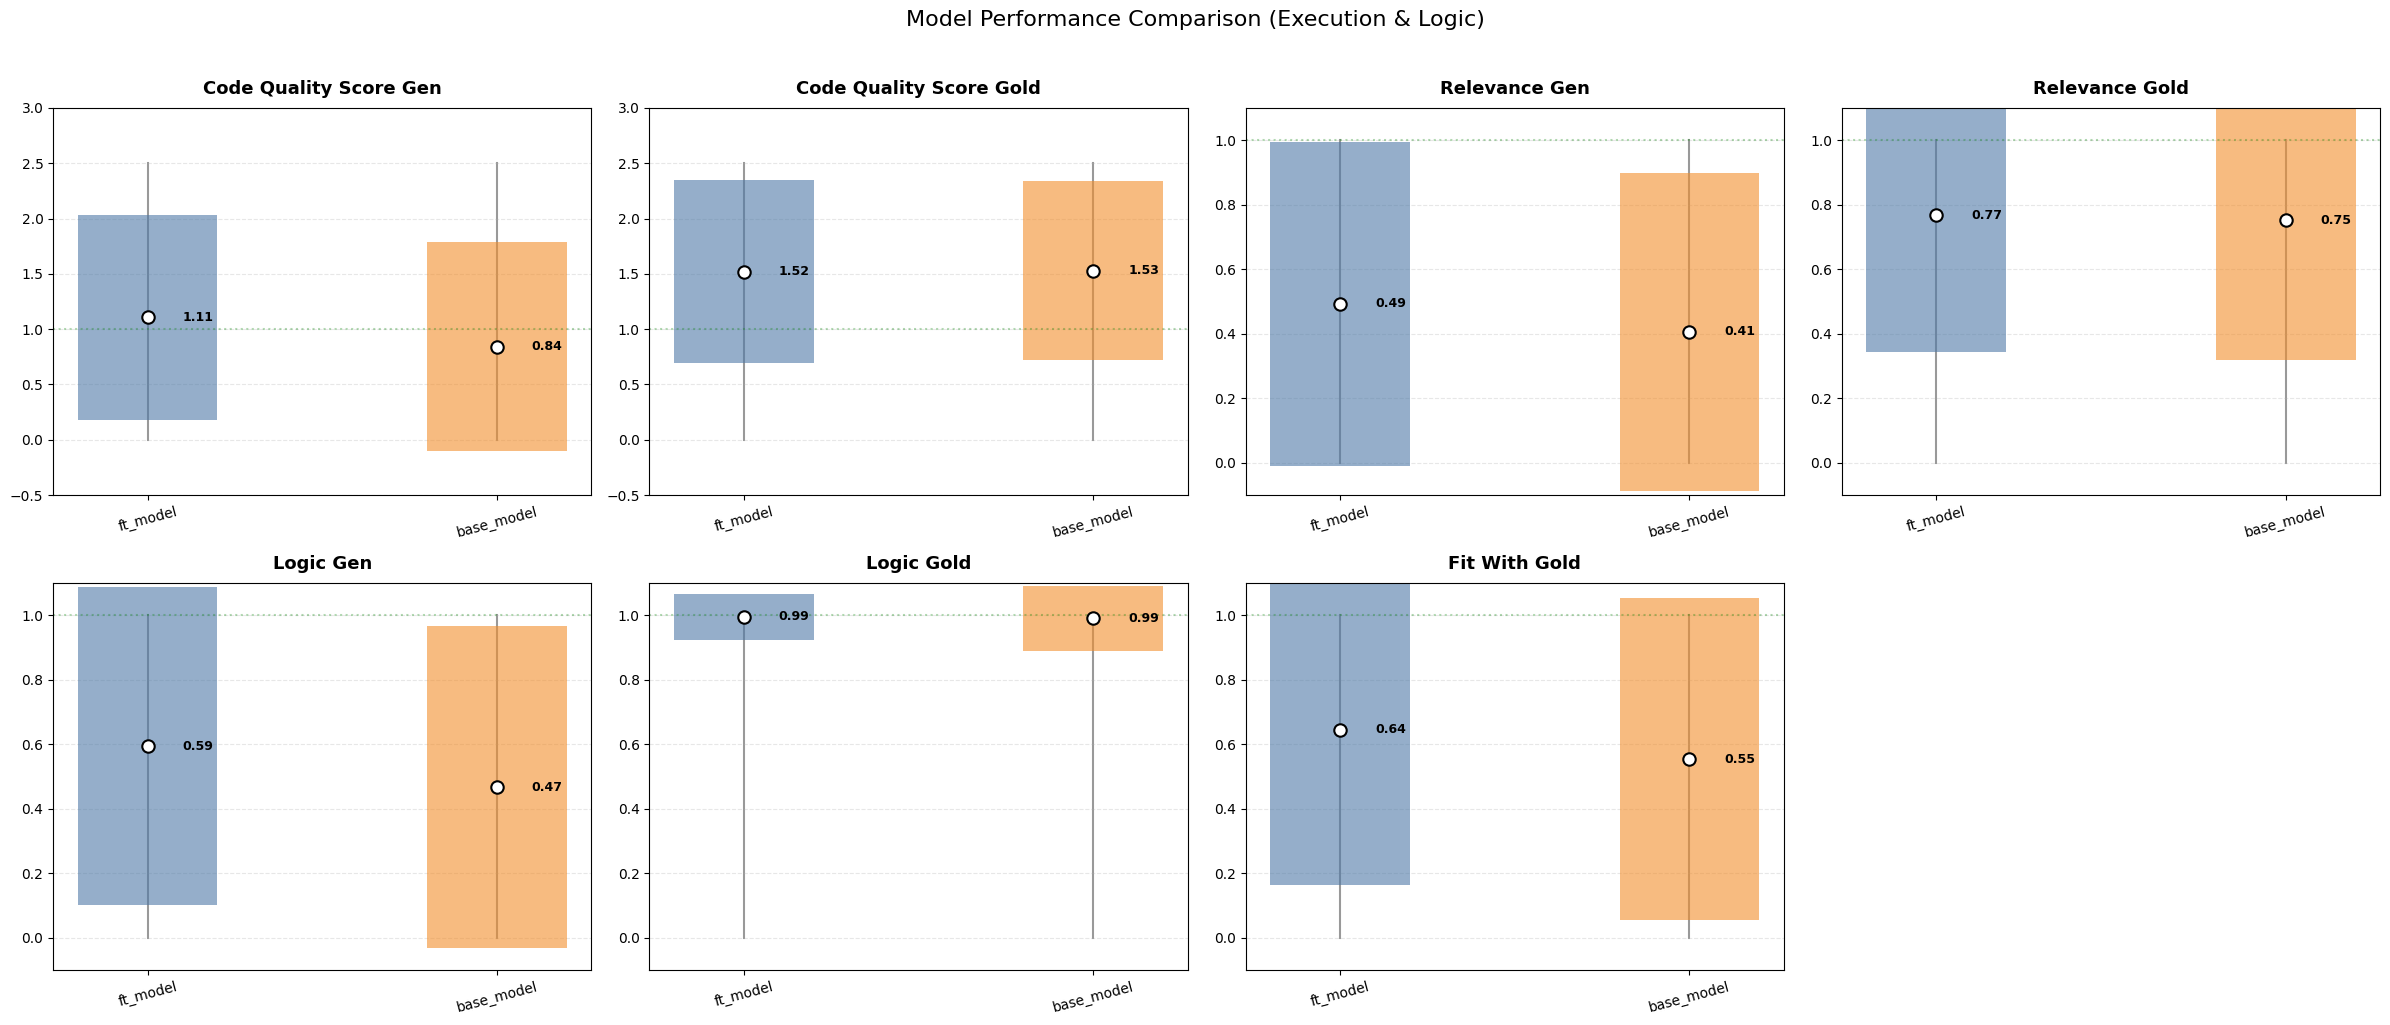

In [ ]:


# Execution remains the same
plot_score_distributions(list_results_df, ['ft_model','base_model'])


In [ ]:
list_results_df[0].to_csv(DATA_DIR/"evaluation_ft_omnisql.csv")
list_results_df[1].to_csv(DATA_DIR/"evaluation_base_omnisql.csv")

#### Ablation study

 Benchmark ready. Master Test Set (DeepSeek): 197 samples.

🔍 Evaluating Base Model (DeepSeek Test Set)...
==((====))==  Unsloth 2026.3.11: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.13.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Step,Training Loss,Validation Loss
10,0.628200,0.181801
20,0.118800,0.103608
30,0.085900,0.085640
40,0.085000,0.080364
50,0.071000,0.077549
60,0.073000,0.076885


Device set to use cuda:0


 Evaluating gpt_oss on DeepSeek Test Set...
Generating 100 samples...


100%|██████████| 25/25 [09:44<00:00, 23.39s/it]


--- Initializing In-Memory Database (Once) ---
--- Data pushed to evaluation connection ---

Processing DataFrame 1/1...
    Executing Queries...
    Running Result Accuracy Judge (DeepSeek)...
    Running Code Quality Judge...

--- Evaluation Complete ---


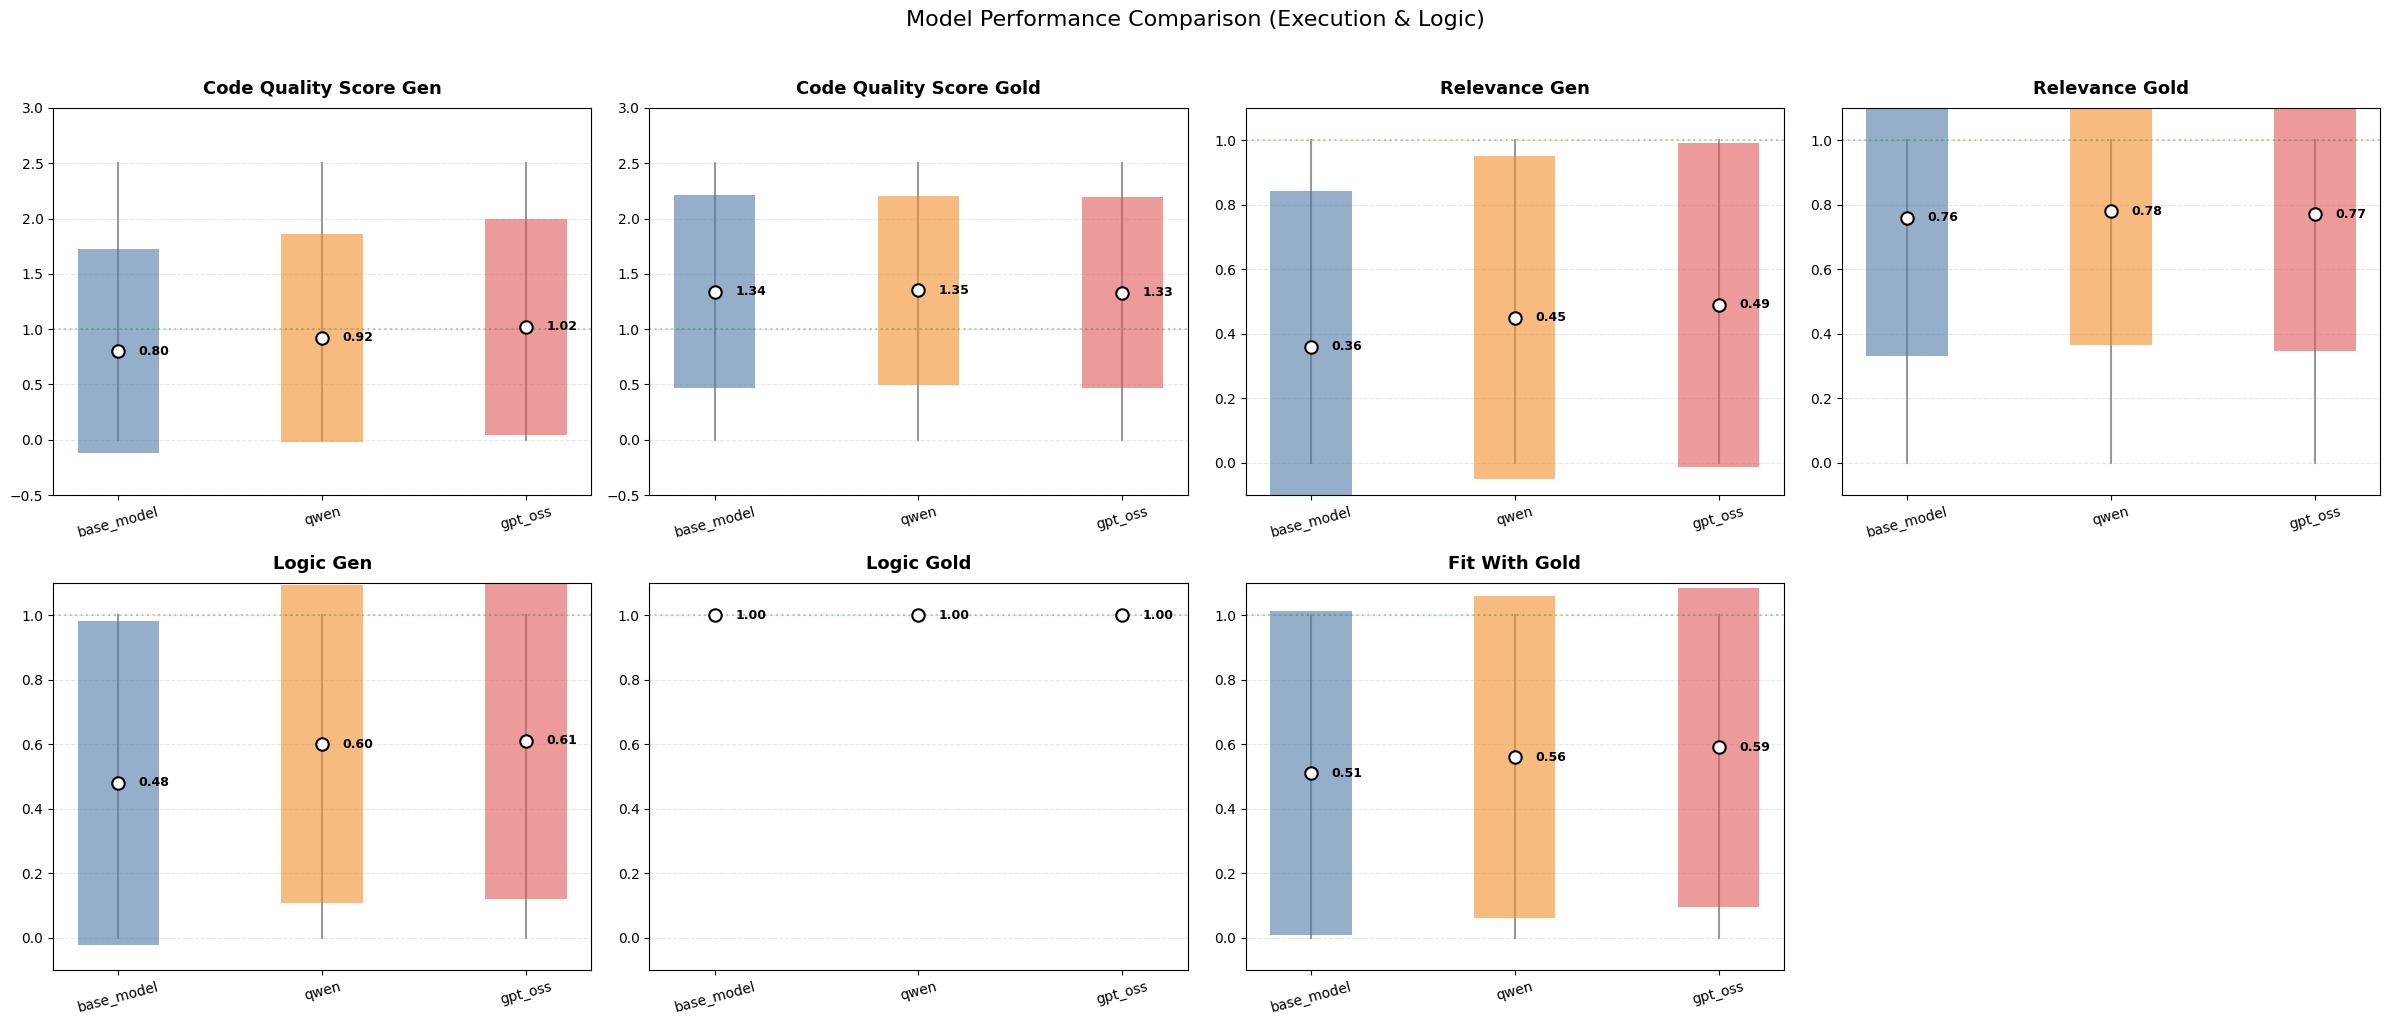

In [ ]:
import os, gc, torch
import pandas as pd
from datasets import Dataset
from trl import SFTTrainer

dataset_configs = {
    "deepseek": DATA_DIR / "advanced_dataset" / "deepseek_candidates.csv",
    "qwen": DATA_DIR / "advanced_dataset" / "qwen_condidates.csv",
    "gpt_oss": DATA_DIR / "advanced_dataset" / "gpt_oss_candidates.csv",
}

train_datasets = {}
val_datasets = {}

ds_df = pd.read_csv(dataset_configs["deepseek"]).dropna(subset=["question_fr", "sql"]).copy()
ds_df["prompt"] = ds_df["question_fr"].apply(build_prompt)
ds_df["answer"] = ds_df["sql"]
master_test_ds = Dataset.from_pandas(ds_df[["prompt", "answer"]])

for name in ["qwen", "gpt_oss"]:
    df = pd.read_csv(dataset_configs[name]).dropna(subset=["question_fr", "sql"]).copy()
    df["prompt"] = df["question_fr"].apply(build_prompt)
    df["answer"] = df["sql"]
    ds = Dataset.from_pandas(df[["prompt", "answer"]])

    split = ds.train_test_split(test_size=0.05, seed=42)
    train_datasets[name] = split["train"]
    val_datasets[name] = split["test"]

print(f" Benchmark ready. Master Test Set (DeepSeek): {len(master_test_ds)} samples.")

evaluation_results = {}

print("\n🔍 Evaluating Base Model (DeepSeek Test Set)...")
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID,
    max_seq_length=4096,
    dtype=torch.bfloat16,
    load_in_4bit=True,
)
base_results_df = run_inference_on_dataset(base_model, base_tokenizer, master_test_ds, max_samples=100)
validator = BudgetDataValidator(validator_dir)
validator.load_data()
base_eval = evaluate_sql_performance([base_results_df], validator, client, sfil_schema)
evaluation_results["base_model"] = base_eval[0]

del base_model, base_tokenizer
gc.collect()
torch.cuda.empty_cache()

for name in train_datasets.keys():
    print(f" Training on dataset: {name}")

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_ID,
        max_seq_length=4096,
        dtype=torch.bfloat16,
        load_in_4bit=True,
    )
    if tokenizer.pad_token is None:
      tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    tokenizer.truncation_side = "left"
    model = FastLanguageModel.get_peft_model(
        model, r=32, target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_alpha=64, lora_dropout=0, bias="none", use_gradient_checkpointing="unsloth",
    )

    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_datasets[name],
        eval_dataset=val_datasets[name],
        formatting_func=format_prompt_train,
        max_seq_length=4096,
        packing=True,
        args=TrainingArguments(
            output_dir=f"./output_{name}",
            per_device_train_batch_size=4,
            gradient_accumulation_steps=4,
            warmup_ratio=0.03,
            num_train_epochs=1,
            learning_rate=2e-4,
            eval_strategy="steps",
            eval_steps=10,
            do_eval=True,
            fp16=not torch.cuda.is_bf16_supported(),
            bf16=torch.cuda.is_bf16_supported(),
            logging_steps=10,
            save_strategy="no",
            optim="paged_adamw_8bit",
            lr_scheduler_type="cosine",
            report_to="none",
        ),
    )
    trainer.train()

    print(f" Evaluating {name} on DeepSeek Test Set...")
    results_df = run_inference_on_dataset(model, tokenizer, master_test_ds, max_samples=100)
    eval_list = evaluate_sql_performance([results_df], validator, client, sfil_schema)
    evaluation_results[name] = eval_list[0]

    del model, tokenizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

final_dfs = list(evaluation_results.values())
final_keys = list(evaluation_results.keys())
plot_score_distributions(final_dfs, final_keys)

In [ ]:
ablation_study_results_dir = DATA_DIR / "ablation_study_results"
ablation_study_results_dir.mkdir(exist_ok=True, parents=True)

for key, df in evaluation_results.items():
    df.to_csv(ablation_study_results_dir / f"{key}.csv")

    print(f"Saved {key} results to {ablation_study_results_dir / f'{key}.csv'}")

Saved base_model results to /content/drive/MyDrive/notebook_drive/ablation_study_results/base_model.csv
Saved qwen results to /content/drive/MyDrive/notebook_drive/ablation_study_results/qwen.csv
Saved gpt_oss results to /content/drive/MyDrive/notebook_drive/ablation_study_results/gpt_oss.csv


In [ ]:
from google.colab import runtime

runtime.unassign()

#### Active learning strategy:

1. Finding the blind spots of the model:

I will test the quality of the queries on different difficulty levels and on different tables.

The idea is to understand which table the model is not very good at and which level of difficulty the model is still strugling with

In [ ]:
import pandas as pd

candidates = pd.read_csv('/content/ttsql_candidates_judged.csv') ### replace this with the right df and done
print(candidates)

passed_candidates = candidates[candidates['judge_pass'] == True]

difficulty_dict = {
    level: group.copy().reset_index(drop=True)
    for level, group in passed_candidates.groupby('difficulty')
}

for level, df in difficulty_dict.items():
    print(f"Level: {level} | Count: {len(df)}")


import ast

candidates['tables_used'] = candidates['tables_used'].apply(ast.literal_eval)

passed_candidates = candidates[candidates['judge_pass'] == True].copy()

exploded_df = passed_candidates.explode('tables_used')

tables_dict = {
    table: group.reset_index(drop=True)
    for table, group in exploded_df.groupby('tables_used')
}

for table_name, df in tables_dict.items():
    print(f"Table: {table_name} | Number of Queries: {len(df)}")

              id                                        question_fr  \
0    cand_000001  Combien de documents avons-nous pour l'année 2...   
1    cand_000002  Quels sont les noms des communes qui ont soumi...   
2    cand_000003  Afficher les documents avec le type de budget ...   
3    cand_000004  Quel est le nombre total de pages pour les doc...   
4    cand_000005      Lister les formats des documents disponibles.   
..           ...                                                ...   
170  cand_000171  Identifiez les communes avec des documents en ...   
171  cand_000172  Pour chaque commune, calculez la variation en ...   
172  cand_000173  Détectez les anomalies budgétaires en identifi...   
173  cand_000174  Évaluez la qualité d'extraction par commune en...   
174  cand_000175  Identifiez les indicateurs financiers qui ont ...   

                                                   sql difficulty  \
0    SELECT COUNT(*) FROM documents WHERE document_...       easy   
1        

Creating datasets:

In [ ]:
def dict_to_hf_datasets(data_dict, question_col="question_fr"):
    """
    Converts a dictionary of DataFrames into a dictionary of HF Datasets
    applying the prompt template to each.
    """
    hf_dict = {}
    for key, df in data_dict.items():
        df["prompt"] = df[question_col].apply(build_prompt)

        hf_dict[key] = Dataset.from_pandas(df[["id", "prompt", "sql"]])

    return hf_dict

tables_dataset = dict_to_hf_datasets(tables_dict)
difficulty_dataset = dict_to_hf_datasets(difficulty_dict)


- Launching inference on the datasets

- Launching the LLM as a judge on all the inferences

In [ ]:
def active_evaluation_pipeline(model):

    #Running inferences

    results_ft_tables = {}
    for table_name, dataset in tables_dataset.items():
      print(f"Evaluating Table: {table_name}")
      results_ft_df = run_inference_on_dataset(
            model, tokenizer, tables_dataset[table_name], max_samples=200
        )
      results_ft_tables[table_name] = results_ft_df

    diff_results_ft = {}
    for difficulty, dataset in difficulty_dataset.items():
      print(f"Evaluating Difficulty: {difficulty}")
      results_ft_df = run_inference_on_dataset(
            model, tokenizer, difficulty_dataset[difficulty], max_samples=200
        )
      diff_results_ft[difficulty] = results_ft_df

    #Validating inferences
    validator = BudgetDataValidator(validator_dir)
    validator.load_data()
    list_of_keys = list(results_ft_tables.keys()) + list(difficulty_dict.keys())
    list_of_dfs = list(results_ft_tables.values()) + list(results_base_df.values())

    list_results_df = evaluate_sql_performance(
        df_list=list_of_dfs,
        validator_instance=validator,
        client=client,
        sfil_schema = sfil_schema
    )

    print(list_results_df[0].head())
    plot_score_distributions(list_results_df, list_of_keys)

active_evaluation_pipeline(model)


2. Training the model on new generated data for its blind spots:

In [ ]:
def refine_model_on_blind_spots(new_data_csv_path, iteration_idx, learning_rate=2e-5):

    extraction_target = "./extracted_current_adapter"
    if os.path.exists(extraction_target):
        shutil.rmtree(extraction_target)

    if iteration_idx == 1:
        zip_source = DATA_DIR / "sql_finetune_adapter_qwen7b_1epoch.zip"
        if not os.path.exists(zip_source):
            raise FileNotFoundError(f"Missing initial zip: {zip_source}")
        shutil.unpack_archive(zip_source, extraction_target, "zip")
    else:
        prev_folder = DATA_DIR / f"active_learning_iter_{iteration_idx - 1}"
        if not os.path.exists(prev_folder):
            raise FileNotFoundError(f"Missing previous iter folder: {prev_folder}")
        shutil.copytree(prev_folder, extraction_target)

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = MODEL_ID,
        max_seq_length = 4096,
        dtype = torch.bfloat16,
        load_in_4bit = True,
    )

    model.load_adapter(extraction_target)

    model = FastLanguageModel.get_peft_model(
        model,
        r=32,
        target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
        lora_alpha=64,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
    )

    df_new = pd.read_csv(new_data_csv_path)
    if 'text_query' not in df_new.columns and 'question' in df_new.columns:
        df_new['text_query'] = df_new['question']
    if 'sql_query' not in df_new.columns and 'sql' in df_new.columns:
        df_new['sql_query'] = df_new['sql']

    df_new["prompt"] = df_new["text_query"].apply(build_prompt)
    df_new["answer"] = df_new["sql_query"]
    correction_dataset = Dataset.from_pandas(df_new[["prompt", "answer"]])

    refine_save_path = f"./active_learning_temp_iter_{iteration_idx}"

    refine_args = TrainingArguments(
        output_dir=refine_save_path,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=learning_rate,
        num_train_epochs=2,
        logging_steps=10,
        save_strategy="no",
        bf16=True,
        optim="paged_adamw_8bit",
        lr_scheduler_type="linear",
        warmup_ratio=0.1,
        report_to="none",
    )

    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=correction_dataset,
        formatting_func=format_prompt_train,
        args=refine_args,
        packing=False,
        max_seq_length=4096,
    )

    gc.collect()
    torch.cuda.empty_cache()

    trainer.train()

    final_adapter_path = DATA_DIR / f"active_learning_iter_{iteration_idx}"
    trainer.save_model(str(final_adapter_path))

    return model, tokenizer

In [ ]:
model,tokenizer = refine_model_on_blind_spots(new_data_csv_path, iteration_idx, learning_rate=2e-5)

active_evaluation_pipeline(model)